In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from scripts.assetsRoster import carteira_AC
# Import the refactored TrendAnalyzer
from soros_system.main import TrendAnalyzer
from soros_system.analysis.markov_vol_model import MarkovVolModel


# Define asset IDs and paths to your data
asset_ids = [
    'bitcoin', 'ethereum', 'solana', 'ripple'
    # Add more assets as needed
]

data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/'
btc_data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/bitcoin_candles.csv'
ssr_data_path='/Users/valter.rebelo/MissionControl/data/onchainData/BTC_SSR.csv'
markov_vol_model = MarkovVolModel.load_model_by_timestamp('20250325_144631')


analyzer = TrendAnalyzer(
    asset_ids=carteira_AC,
     data_path=data_path,
     btc_data_path=btc_data_path,
     lookback_days='all',
     ssr_data_path=ssr_data_path,        
     markov_analyzer=markov_vol_model  
 )

# Analyze all assets
results = analyzer.analyze_multiple_assets()


In [ ]:
# Get BTC return data
btc_data = analyzer.get_asset_information('bitcoin').get('processed_data')[['date', 'returns_usd', 'close']]


Detected 0 change points at indices: []
Change point dates: []


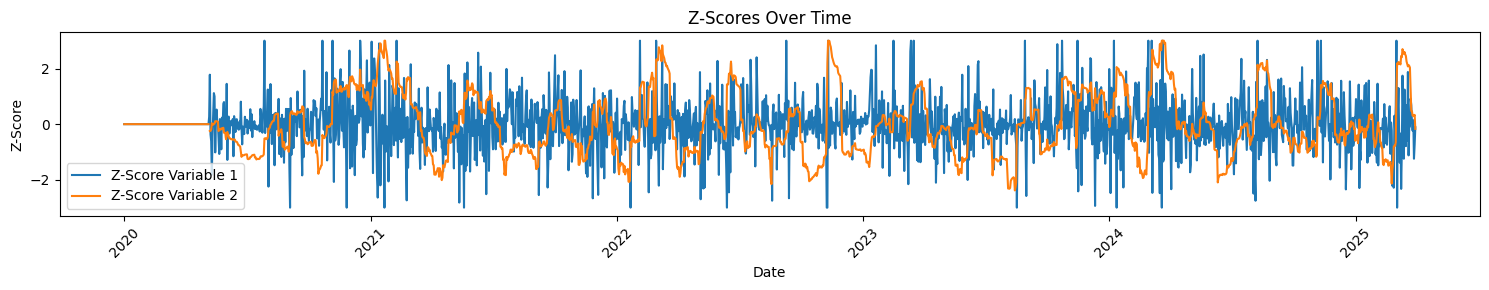

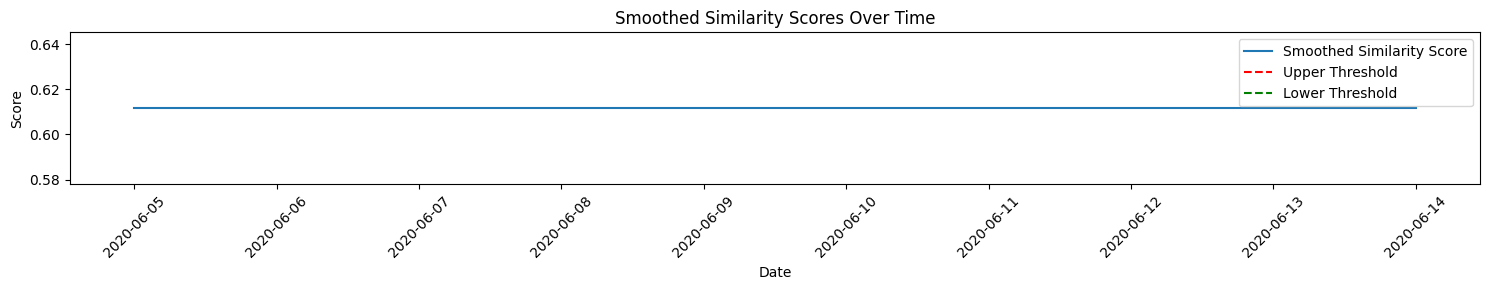

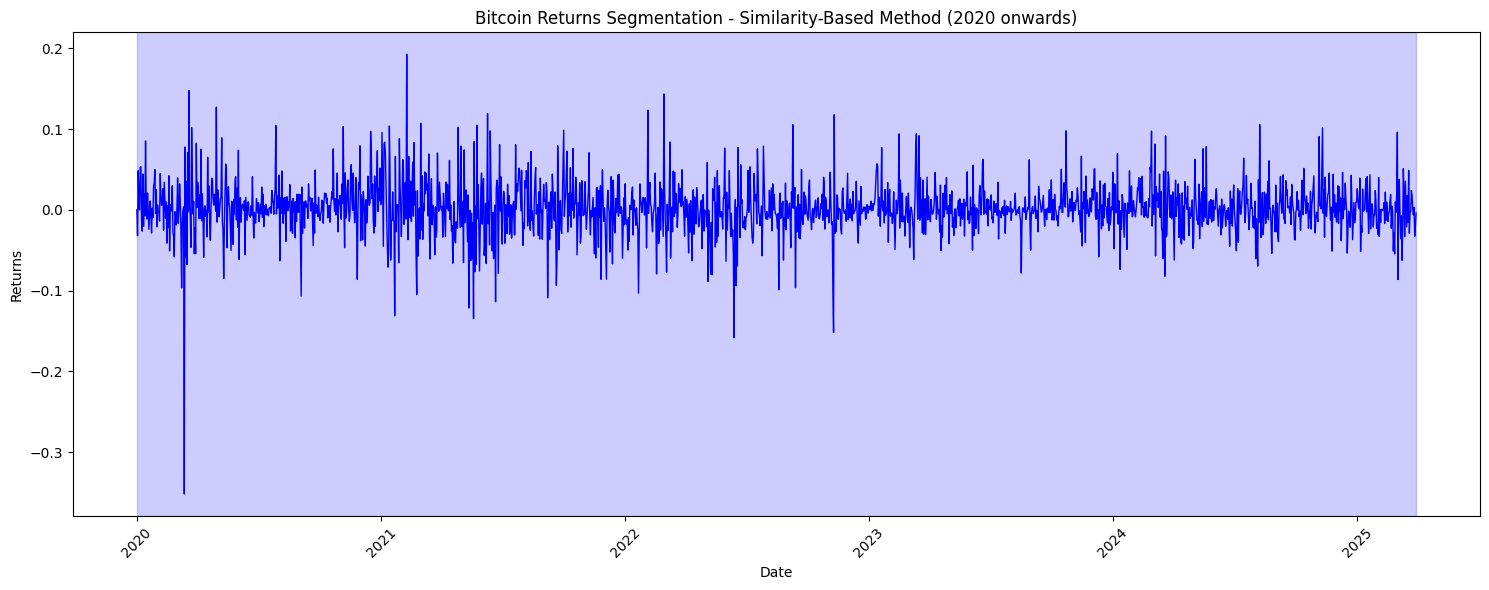

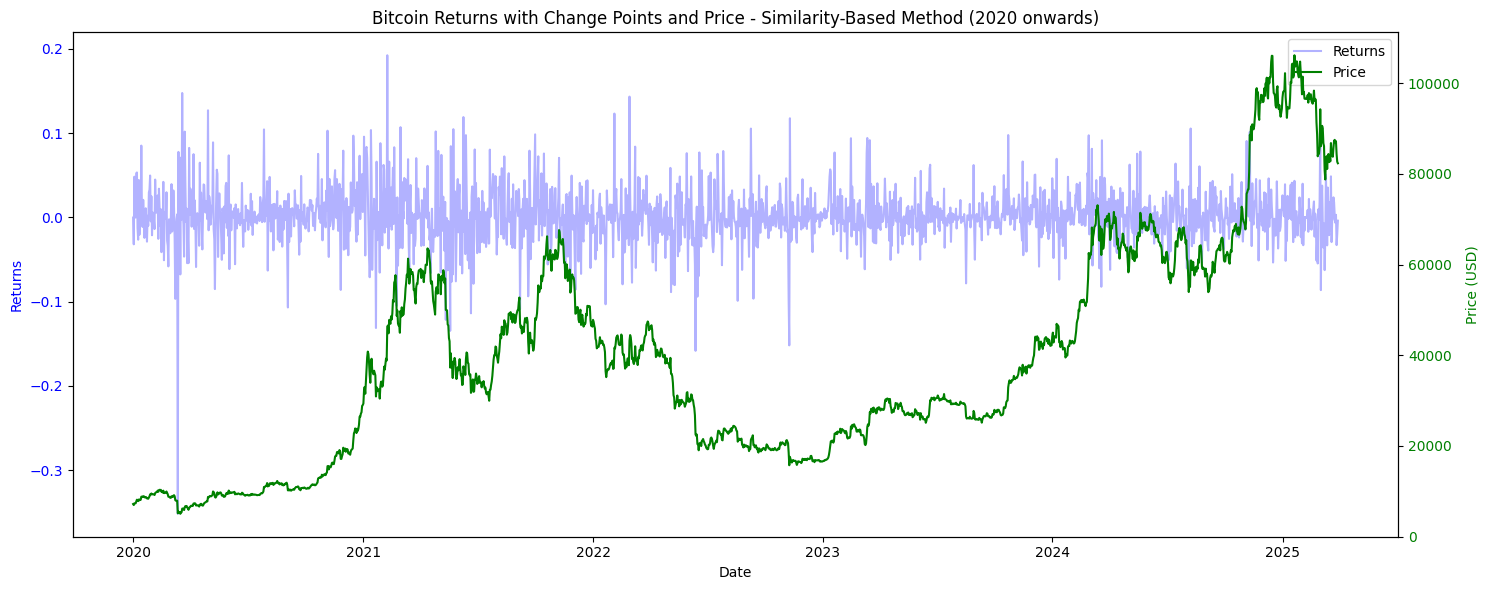

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Get BTC return data (assuming analyzer is defined elsewhere)
btc_data = analyzer.get_asset_information('bitcoin').get('processed_data')[['date', 'returns_usd', 'close']]

# Filter data from 2020 onwards
btc_data['date'] = pd.to_datetime(btc_data['date'])
btc_data_2020 = btc_data[btc_data['date'] >= '2020-01-01']

# Clean data by removing NaN values
clean_btc_data = btc_data_2020.dropna().reset_index(drop=True)
btc_returns = clean_btc_data['returns_usd'].values
btc_prices = clean_btc_data['close'].values
btc_dates = clean_btc_data['date'].values

# Compute Bitcoin volatility as an additional variable
btc_volatility = pd.Series(btc_returns).rolling(window=21, min_periods=1).std().values  # 21-day rolling volatility

# Compute z-scores for multiple variables
lookback = 126  # Reduced to 6 months for daily data
variables = [btc_returns, btc_volatility]  # Add more variables if available
z_scores_list = []
for var in variables:
    z_scores = np.zeros(len(var))
    for t in range(lookback, len(var)):
        window = var[t - lookback:t]
        mean = np.mean(window)
        std = np.std(window)
        z_scores[t] = (var[t] - mean) / (std + 1e-6)  # Avoid division by zero
    z_scores = np.clip(z_scores, -3, 3)  # Winsorize at ±3
    z_scores_list.append(z_scores)

# Compute similarity scores and detect regimes
exclude_days = 30  # Reduced to 30 days
similarity_threshold = 0.1  # Top 10% most similar days
smooth_window = 10  # Smoothing window for similarity scores
change_points = []
similarity_scores = []

for t in range(lookback + exclude_days, len(btc_returns)):
    # Compute Euclidean distances across all variables
    distances = np.zeros(t - exclude_days)
    for z_scores in z_scores_list:
        historical_z_scores = z_scores[:t - exclude_days]
        current_z_score = z_scores[t]
        distances += (historical_z_scores - current_z_score) ** 2
    distances = np.sqrt(distances)
    
    # Store the average similarity score
    similarity_scores.append(np.mean(distances))

# Smooth the similarity scores
similarity_scores = pd.Series(similarity_scores).rolling(window=smooth_window, min_periods=1).mean().values

# Detect change points based on similarity score thresholds
threshold_upper = np.percentile(similarity_scores, 75)  # Upper threshold for high dissimilarity
threshold_lower = np.percentile(similarity_scores, 25)  # Lower threshold for high similarity
for t in range(1, len(similarity_scores)):
    if t < len(similarity_scores) - 1:  # Avoid edge effects
        # Detect a change when crossing thresholds
        if (similarity_scores[t-1] < threshold_lower and similarity_scores[t] > threshold_upper) or \
           (similarity_scores[t-1] > threshold_upper and similarity_scores[t] < threshold_lower):
            change_points.append(t + lookback + exclude_days)

# Print detected change points
print(f"Detected {len(change_points)} change points at indices: {change_points}")
change_point_dates = [clean_btc_data['date'].iloc[cp].strftime('%Y-%m-%d') for cp in change_points]
print(f"Change point dates: {change_point_dates}")

# Plot the z-scores for debugging
plt.figure(figsize=(15, 3))
for i, z_scores in enumerate(z_scores_list):
    plt.plot(btc_dates, z_scores, label=f'Z-Score Variable {i+1}')
plt.title('Z-Scores Over Time')
plt.xlabel('Date')
plt.ylabel('Z-Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the smoothed similarity scores
plt.figure(figsize=(15, 3))
plt.plot(btc_dates[lookback + exclude_days:], similarity_scores, label='Smoothed Similarity Score')
plt.axhline(y=threshold_upper, color='r', linestyle='--', label='Upper Threshold')
plt.axhline(y=threshold_lower, color='g', linestyle='--', label='Lower Threshold')
plt.title('Smoothed Similarity Scores Over Time')
plt.xlabel('Date')
plt.ylabel('Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 1: Segmentation with colored backgrounds
plt.figure(figsize=(15, 6))
bkps = [0] + change_points + [len(btc_returns)]
bkps.sort()

for i in range(len(bkps) - 1):
    start, end = bkps[i], bkps[i + 1]
    segment_dates = btc_dates[start:end]
    segment_returns = btc_returns[start:end]
    plt.plot(segment_dates, segment_returns, 'b-', linewidth=1)
    color = 'blue' if i % 2 == 0 else 'red'
    plt.axvspan(segment_dates[0], segment_dates[-1], alpha=0.2, color=color)

for cp in change_points:
    plt.axvline(x=btc_dates[cp], color='r', linestyle='--')

plt.title('Bitcoin Returns Segmentation - Similarity-Based Method (2020 onwards)')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.xticks(rotation=45)
plt.tight_layout()

# Plot 2: Returns with Price Overlay
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(111)

# Plot returns
ax1.plot(clean_btc_data['date'], btc_returns, color='blue', alpha=0.3, label='Returns')
ax1.set_xlabel('Date')
ax1.set_ylabel('Returns', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot price on second y-axis
ax2 = ax1.twinx()
ax2.plot(clean_btc_data['date'], btc_prices, color='green', label='Price')
ax2.set_ylabel('Price (USD)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add change point lines
for cp in change_points:
    plt.axvline(x=clean_btc_data['date'].iloc[cp], color='r', linestyle='--',
                label=f"Change point: {clean_btc_data['date'].iloc[cp].strftime('%Y-%m-%d')}")

# Handle legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), loc='best')

plt.title('Bitcoin Returns with Change Points and Price - Similarity-Based Method (2020 onwards)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()